In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [3]:
df.shape


(27, 2)

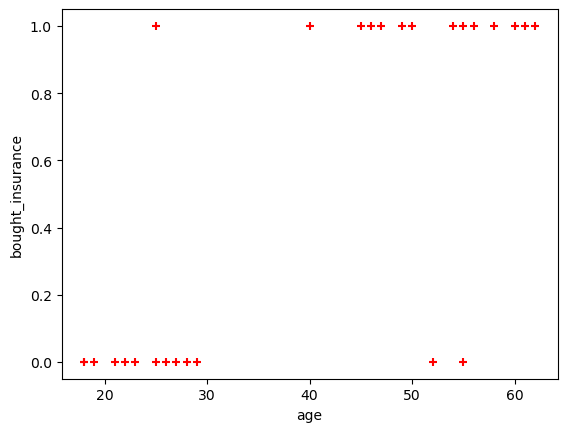

In [6]:
plt.xlabel('age')
plt.ylabel('bought_insurance')
plt.scatter(df.age,df.bought_insurance,color='red',marker='+')


In [7]:
x=df[['age']]
y=df['bought_insurance']

In [8]:
from sklearn.model_selection import train_test_split     

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=10)

In [13]:
x_test

,age
7,60
5,56
18,19
21,26
11,28
1,25


In [15]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [16]:
model.coef_

array([[0.112778]])

In [17]:
model.intercept_

array([-4.20278276])

In [18]:
y_predicted=model.predict(x_test)

In [19]:
y_predicted

array([1, 1, 0, 0, 0, 0], dtype=int64)

In [20]:
df['probs']=model.predict_proba(df[['age']])[:,1]

In [21]:
df

,age,bought_insurance,probs
0,22,0,0.151657
1,25,0,0.200474
2,47,1,0.749845
3,52,0,0.840463
4,46,1,0.728100
5,56,1,0.892140
6,55,0,0.880798
7,60,1,0.928502
8,62,1,0.942103
9,61,1,0.935636


Text(0, 0.5, 'bought_insurance')

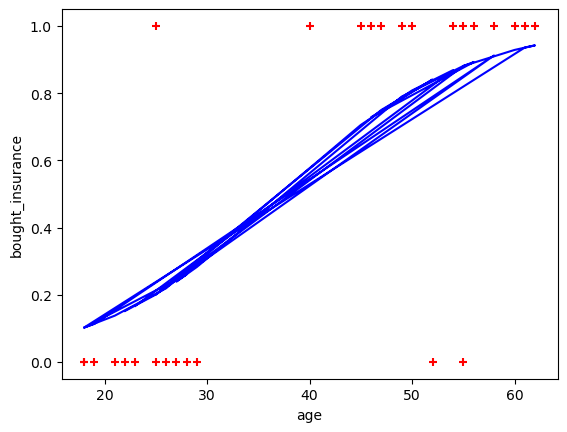

In [22]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')
plt.plot(df['age'],df['probs'],color='blue')
plt.xlabel("age")
plt.ylabel("bought_insurance")

In [23]:
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))

In [24]:
def prediction_function(age):
    z=0.112*age+(-4.20)
    y=sigmoid(z)
    return y

In [25]:
age=35
prediction_function(age)

0.43045377606077095

In [26]:
age=40
prediction_function(age)


0.569546223939229

In [27]:
age=37.5
prediction_function(age)


0.5

In [28]:
age=82
prediction_function(age)


0.9931999362344026

In [29]:
age=66
prediction_function(age)


0.9605321106735979

In [30]:
age=58
prediction_function(age)


0.9085452184644403

In [31]:
age=77
prediction_function(age)


0.9881557756401541

In [32]:
age=13
prediction_function(age)


0.0604264033944818

In [33]:
age=1
prediction_function(age)


0.016496061288316648

In [34]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x)
accuracy=accuracy_score(y,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8888888888888888
